In [1]:
import torch
print(torch.__version__)

2.5.1


In [2]:
import torchvision
import torchvision.transforms as transforms

# 定义数据预处理：转为张量并标准化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 下载训练集（第一次运行会自动下载，可能稍慢）
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

# 取一个批次的数据
dataiter = iter(trainloader)
images, labels = next(dataiter)

print("images 形状:", images.shape)   # 应输出 torch.Size([32, 1, 28, 28])
print("labels 形状:", labels.shape)   # 应输出 torch.Size([32])

images 形状: torch.Size([32, 1, 28, 28])
labels 形状: torch.Size([32])


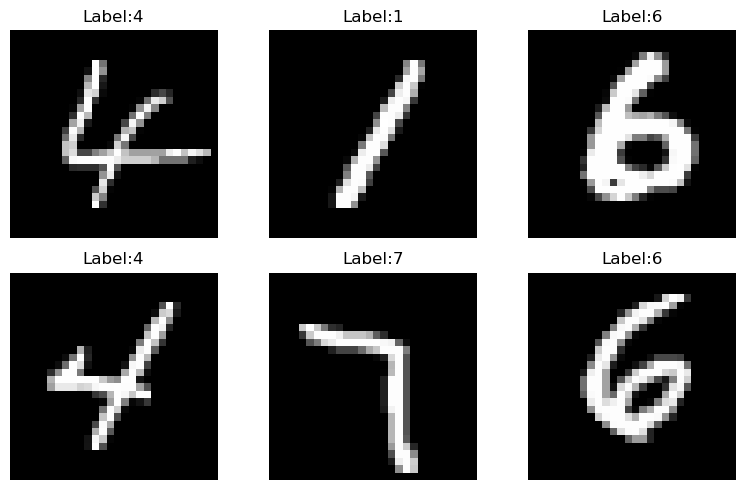

In [4]:
import matplotlib.pyplot as plt

#显示前6张图片
fig, axes=plt.subplots(2,3,figsize=(8,5))
for i,ax in enumerate(axes.flat):
    img=images[i].squeeze() #去掉通道维度(1,28,28) -> (28,28)
    ax.imshow(img,cmap='gray')
    ax.set_title(f'Label:{labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
#从列表创建张量
a=torch.tensor([[1,2],[3,4]])
print("a:\n",a) #打印a的含义？

#全零张量
b=torch.zeros(3,4)
print("b:\n",b)

#全一张量
c=torch.ones(2,3)
print("c:\n",c)

#随机张量
d=torch.randn(2,3)
print("d:\n",d)






























a:
 tensor([[1, 2],
        [3, 4]])
b:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
c:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
d:
 tensor([[-0.4687,  0.3638,  0.6393],
        [ 0.4105,  0.0282,  0.0369]])


In [8]:
x=torch.randn(4,6)
print("原始形状:",x.shape)

# view 改变形状（要求元素总数不变）
y=x.view(3,8)
print("xiew(3,8) 形状：",y.shape)

#reshape 类似，但更灵活
z=x.reshape(2,12)
print("reshape(2,12) 形状：",z.shape)

# 拼接两个张量
x1=torch.randn(2,3)
x2=torch.randn(2,3)
cat_row=torch.cat((x1,x2),dim=0)  #按行拼接
cat_col=torch.cat((x1,x2),dim=1)  #按列拼接
print("cat_row 形状：",cat_row.shape)
print("cat_col 形状: ",cat_col.shape)


































原始形状: torch.Size([4, 6])
xiew(3,8) 形状： torch.Size([3, 8])
reshape(2,12) 形状： torch.Size([2, 12])
cat_row 形状： torch.Size([4, 3])
cat_col 形状:  torch.Size([2, 6])


In [11]:
x=torch.randn(3,4)
print("x:\n",x)

#取第一行
print("第一行：",x[0,:])

#取第二列
print("第二列：",x[:,1])

#取前两行后两列
print("子区域:\n",x[:2,2:])

#布尔索引（选出大于0的元素）
print("大于0的元素:",x[x>0])


x:
 tensor([[-0.6934, -1.6135, -2.2819,  2.0329],
        [-2.6666,  0.6347,  1.0212,  0.7118],
        [-0.0087, -0.5531, -0.9948, -0.0058]])
第一行： tensor([-0.6934, -1.6135, -2.2819,  2.0329])
第二列： tensor([-1.6135,  0.6347, -0.5531])
子区域:
 tensor([[-2.2819,  2.0329],
        [ 1.0212,  0.7118]])
大于0的元素: tensor([2.0329, 0.6347, 1.0212, 0.7118])


In [17]:
a=torch.tensor([1,2,3])
b=torch.tensor([4,5,6])

#逐元素加法
print("a+b=",a+b)

#矩阵乘法（需调整形状)
a_mat=a.view(1,3)
b_mat=b.view(3,1)
print("矩阵乘法:\n",torch.matmul(a_mat,b_mat))

#求和、均值
print("a的值:",a.sum())
print("b的均值:",b.float().mean().item())

a+b= tensor([5, 7, 9])
矩阵乘法:
 tensor([[32]])
a的值: tensor(6)
b的均值: 5.0
